In [1]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset   # ← added Subset
from torchvision import datasets, transforms

from sklearn.model_selection import StratifiedKFold              # ← added
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ---------------------------------------------------------------
# HYPERPARAMETERS — keep these IDENTICAL to your Task 2 notebook
# This is required by the assignment for fair comparison
# ---------------------------------------------------------------

DATA_DIR    = Path('/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer/Brain Cancer')
IMG_SIZE    = 224       # resize every image to 224×224 pixels
BATCH_SIZE  = 32        # 32 images processed at once during training
LR          = 1e-3      # learning rate = how big each weight update step is
NUM_EPOCHS  = 50        # maximum training rounds (increased to 50)
PATIENCE    = 5         # stop early if val loss doesn't improve for 5 epochs
TRAIN_SPLIT = 0.80      # 80% of data → training
VAL_SPLIT   = 0.10      # 10% → validation (monitor overfitting)
TEST_SPLIT  = 0.10      # 10% → final test (never seen during training)
WEIGHT_DECAY= 1e-4      # L2 regularization to prevent overfitting

# Auto-detect class folder names (glioma, meningioma, etc.)
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')
print(f'Train/Val/Test    : {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}')
print(f'Max Epochs        : {NUM_EPOCHS}')

Number of classes : 3
Class names       : ['brain_glioma', 'brain_menin', 'brain_tumor']
Train/Val/Test    : 0.8/0.1/0.1
Max Epochs        : 50


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset TWICE — train folds use augmentation, val fold does not
full_train_ds = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
full_val_ds   = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)

# Extract all labels — needed by StratifiedKFold to keep class balance per fold
all_labels_kfold = np.array([label for _, label in full_train_ds.samples])

print(f'Total images : {len(all_labels_kfold)}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls}: {(all_labels_kfold == i).sum()} images')

Total images : 15000
  brain_glioma: 5000 images
  brain_menin: 5000 images
  brain_tumor: 5000 images


In [4]:
# ---------------------------------------------------------------
# BUILDING THE CUSTOM CNN FROM SCRATCH
#
# A ConvBlock is the repeated unit of a CNN:
#   Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool
#
# Conv2d:      scans the image with a small filter to detect features
#              (edges, textures, shapes)
# BatchNorm:   normalizes outputs so training is stable and faster
# ReLU:        activation function — sets negatives to 0 (adds non-linearity)
# MaxPool:     reduces spatial size by half (keeps strongest feature in region)
# ---------------------------------------------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        # in_ch  = number of input channels (e.g. 3 for RGB, 32 for next block)
        # out_ch = number of filters to learn (32, 64, 128, etc.)
        # pool   = whether to halve the spatial size with MaxPool
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            # kernel_size=3 → 3×3 filter slides over the image
            # padding=1 → adds 1 pixel border so output size matches input size
            # bias=False → BatchNorm handles the bias, so we don't need it here
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),   # inplace=True saves memory
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
            # kernel=2, stride=2 → cuts width and height in half
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Architecture overview:
    Input: (Batch, 3, 224, 224)   ← 3-channel RGB image
      Block 1: 3→32   + pool  → (B, 32,  112, 112)
      Block 2: 32→64  + pool  → (B, 64,   56,  56)
      Block 3: 64→128 + pool  → (B, 128,  28,  28)
      Block 4: 128→256+ pool  → (B, 256,  14,  14)
      Block 5: 256→512+ pool  → (B, 512,   7,   7)
      AdaptiveAvgPool          → (B, 512,   1,   1)
      Flatten                  → (B, 512)
      Linear 512→256 + ReLU
      Dropout
      Linear 256→num_classes   → final prediction
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # Feature extractor: stacked ConvBlocks
        # Each block learns increasingly complex features:
        # Block1 = edges/corners, Block2 = textures, Block3+ = shapes/structures
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )

        # Reduces any spatial size to 1×1 (makes model flexible to image sizes)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classifier head: takes the 512 feature vector → class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),             # (B,512,1,1) → (B,512)
            nn.Linear(512, 256),      # fully connected: 512 inputs → 256 outputs
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),      # randomly zeroes 50% of neurons during training
                                      # → prevents the model from memorizing training data
            nn.Linear(256, num_classes)  # final layer: 256 → number of cancer classes
        )

    def forward(self, x):
        x = self.features(x)    # extract features
        x = self.pool(x)        # global average pooling
        return self.classifier(x)  # classify


# Create model and send to GPU/CPU
model = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

Model architecture:
CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (

In [5]:

# ---------------------------------------------------------------
# CrossEntropyLoss: standard loss for multi-class classification
#   It measures how wrong the model's predictions are
#   Lower loss = model is more confident and correct
#
# Adam optimizer: updates the model weights after each batch
#   It adapts the learning rate per parameter automatically
#   weight_decay adds L2 penalty → keeps weights small → less overfitting
#
# ReduceLROnPlateau scheduler:
#   If val loss doesn't improve for 3 epochs → halve the learning rate
#   This helps the model fine-tune more carefully later in training
# ---------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # multiply LR by 0.5 when triggered
    patience=3,       # wait 3 epochs before reducing
)
print('Loss, optimizer, and scheduler are ready.')

Loss, optimizer, and scheduler are ready.


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # new_lr = old_lr × 0.5 when triggered
    patience=3,       # wait 3 epochs of no improvement before reducing
)

print('Loss, optimizer, and scheduler are ready.')

# Optional: check your PyTorch version
print(f'PyTorch version: {torch.__version__}')

Loss, optimizer, and scheduler are ready.
PyTorch version: 2.10.0+cu128


In [7]:
# ---------------------------------------------------------------
# HELPER FUNCTIONS — same as before
# ---------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += imgs.size(0)
    return running_loss / total, correct / total


# ---------------------------------------------------------------
# 5-FOLD CROSS VALIDATION TRAINING LOOP
# ---------------------------------------------------------------

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_histories = []   # store history of each fold for plotting
fold_metrics   = []   # store metrics of each fold for summary

print(f'Starting {N_FOLDS}-Fold Cross Validation')
print('=' * 60)

train_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(all_labels_kfold)), all_labels_kfold)):
    print(f'\n>>> FOLD {fold+1}/{N_FOLDS}  |  Train: {len(train_idx)}  Val: {len(val_idx)}')

    set_seed(SEED + fold)

    # train fold gets augmentation, val fold does not
    train_loader = DataLoader(Subset(full_train_ds, train_idx),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(full_val_ds, val_idx),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    # Re-initialize model fresh for every fold
    model     = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_path  = f'best_custom_cnn_fold{fold+1}.pth'

    for epoch in range(NUM_EPOCHS):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
              f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

        if v_loss < best_val_loss:
            best_val_loss    = v_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f'  ✓ Best model saved (val_loss={v_loss:.4f})')
        else:
            patience_counter += 1
            print(f'  No improvement ({patience_counter}/{PATIENCE})')
            if patience_counter >= PATIENCE and epoch + 1 >= 5:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

    fold_histories.append(history)

    # Evaluate this fold
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    model.eval()
    fold_preds, fold_true = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            fold_preds.extend(outputs.argmax(1).cpu().numpy())
            fold_true.extend(labels.numpy())

    fold_acc = accuracy_score(fold_true, fold_preds)
    fold_f1  = f1_score(fold_true, fold_preds, average='weighted', zero_division=0)
    fold_metrics.append({'fold': fold+1, 'accuracy': fold_acc, 'f1': fold_f1})
    print(f'\n  Fold {fold+1} → Acc: {fold_acc:.4f} | F1: {fold_f1:.4f}')

train_time = time.time() - train_start
print(f'\nTotal Training Time: {train_time:.1f} seconds')

# ---------------------------------------------------------------
# K-FOLD SUMMARY
# ---------------------------------------------------------------
print('\n' + '='*50)
print(f'  5-FOLD CROSS VALIDATION SUMMARY')
print('='*50)
for r in fold_metrics:
    print(f'  Fold {r["fold"]}  →  Acc: {r["accuracy"]:.4f}  |  F1: {r["f1"]:.4f}')
mean_acc = np.mean([r['accuracy'] for r in fold_metrics])
mean_f1  = np.mean([r['f1']      for r in fold_metrics])
std_acc  = np.std( [r['accuracy'] for r in fold_metrics])
std_f1   = np.std( [r['f1']      for r in fold_metrics])
print(f'  Mean Acc : {mean_acc:.4f} ± {std_acc:.4f}')
print(f'  Mean F1  : {mean_f1:.4f} ± {std_f1:.4f}')
print('='*50)

# Use the last fold's model and val_loader for remaining cells (plots, metrics, ROC)
# This keeps all your downstream cells (8, 9, 10, 11, 12) working without any change

Starting 5-Fold Cross Validation

>>> FOLD 1/5  |  Train: 12000  Val: 3000
Epoch [01/50]  Train Loss: 0.5159  Train Acc: 0.7864  Val Loss: 0.9454  Val Acc: 0.6803
  ✓ Best model saved (val_loss=0.9454)
Epoch [02/50]  Train Loss: 0.2997  Train Acc: 0.8874  Val Loss: 8.3307  Val Acc: 0.3463
  No improvement (1/5)
Epoch [03/50]  Train Loss: 0.2496  Train Acc: 0.9066  Val Loss: 0.5398  Val Acc: 0.7783
  ✓ Best model saved (val_loss=0.5398)
Epoch [04/50]  Train Loss: 0.2077  Train Acc: 0.9217  Val Loss: 0.5567  Val Acc: 0.8130
  No improvement (1/5)
Epoch [05/50]  Train Loss: 0.1929  Train Acc: 0.9307  Val Loss: 0.5015  Val Acc: 0.8010
  ✓ Best model saved (val_loss=0.5015)
Epoch [06/50]  Train Loss: 0.1594  Train Acc: 0.9426  Val Loss: 0.1192  Val Acc: 0.9573
  ✓ Best model saved (val_loss=0.1192)
Epoch [07/50]  Train Loss: 0.1488  Train Acc: 0.9467  Val Loss: 0.1610  Val Acc: 0.9410
  No improvement (1/5)
Epoch [08/50]  Train Loss: 0.1476  Train Acc: 0.9467  Val Loss: 0.6447  Val Acc: 0.8

In [8]:
# ---------------------------------------------------------------
# DEFINE TEST LOADER — required for all cells below
# ---------------------------------------------------------------

# Re-create full_val_ds in case it's not in memory
full_val_ds = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)

n_total = len(full_val_ds)
n_test  = int(TEST_SPLIT * n_total)
n_rest  = n_total - n_test

_, test_ds = torch.utils.data.random_split(
    full_val_ds, [n_rest, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
print(f'Test set size : {n_test} images')
print(f'Using best model: {best_model_path}')

Test set size : 1500 images
Using best model: best_custom_cnn_fold5.pth


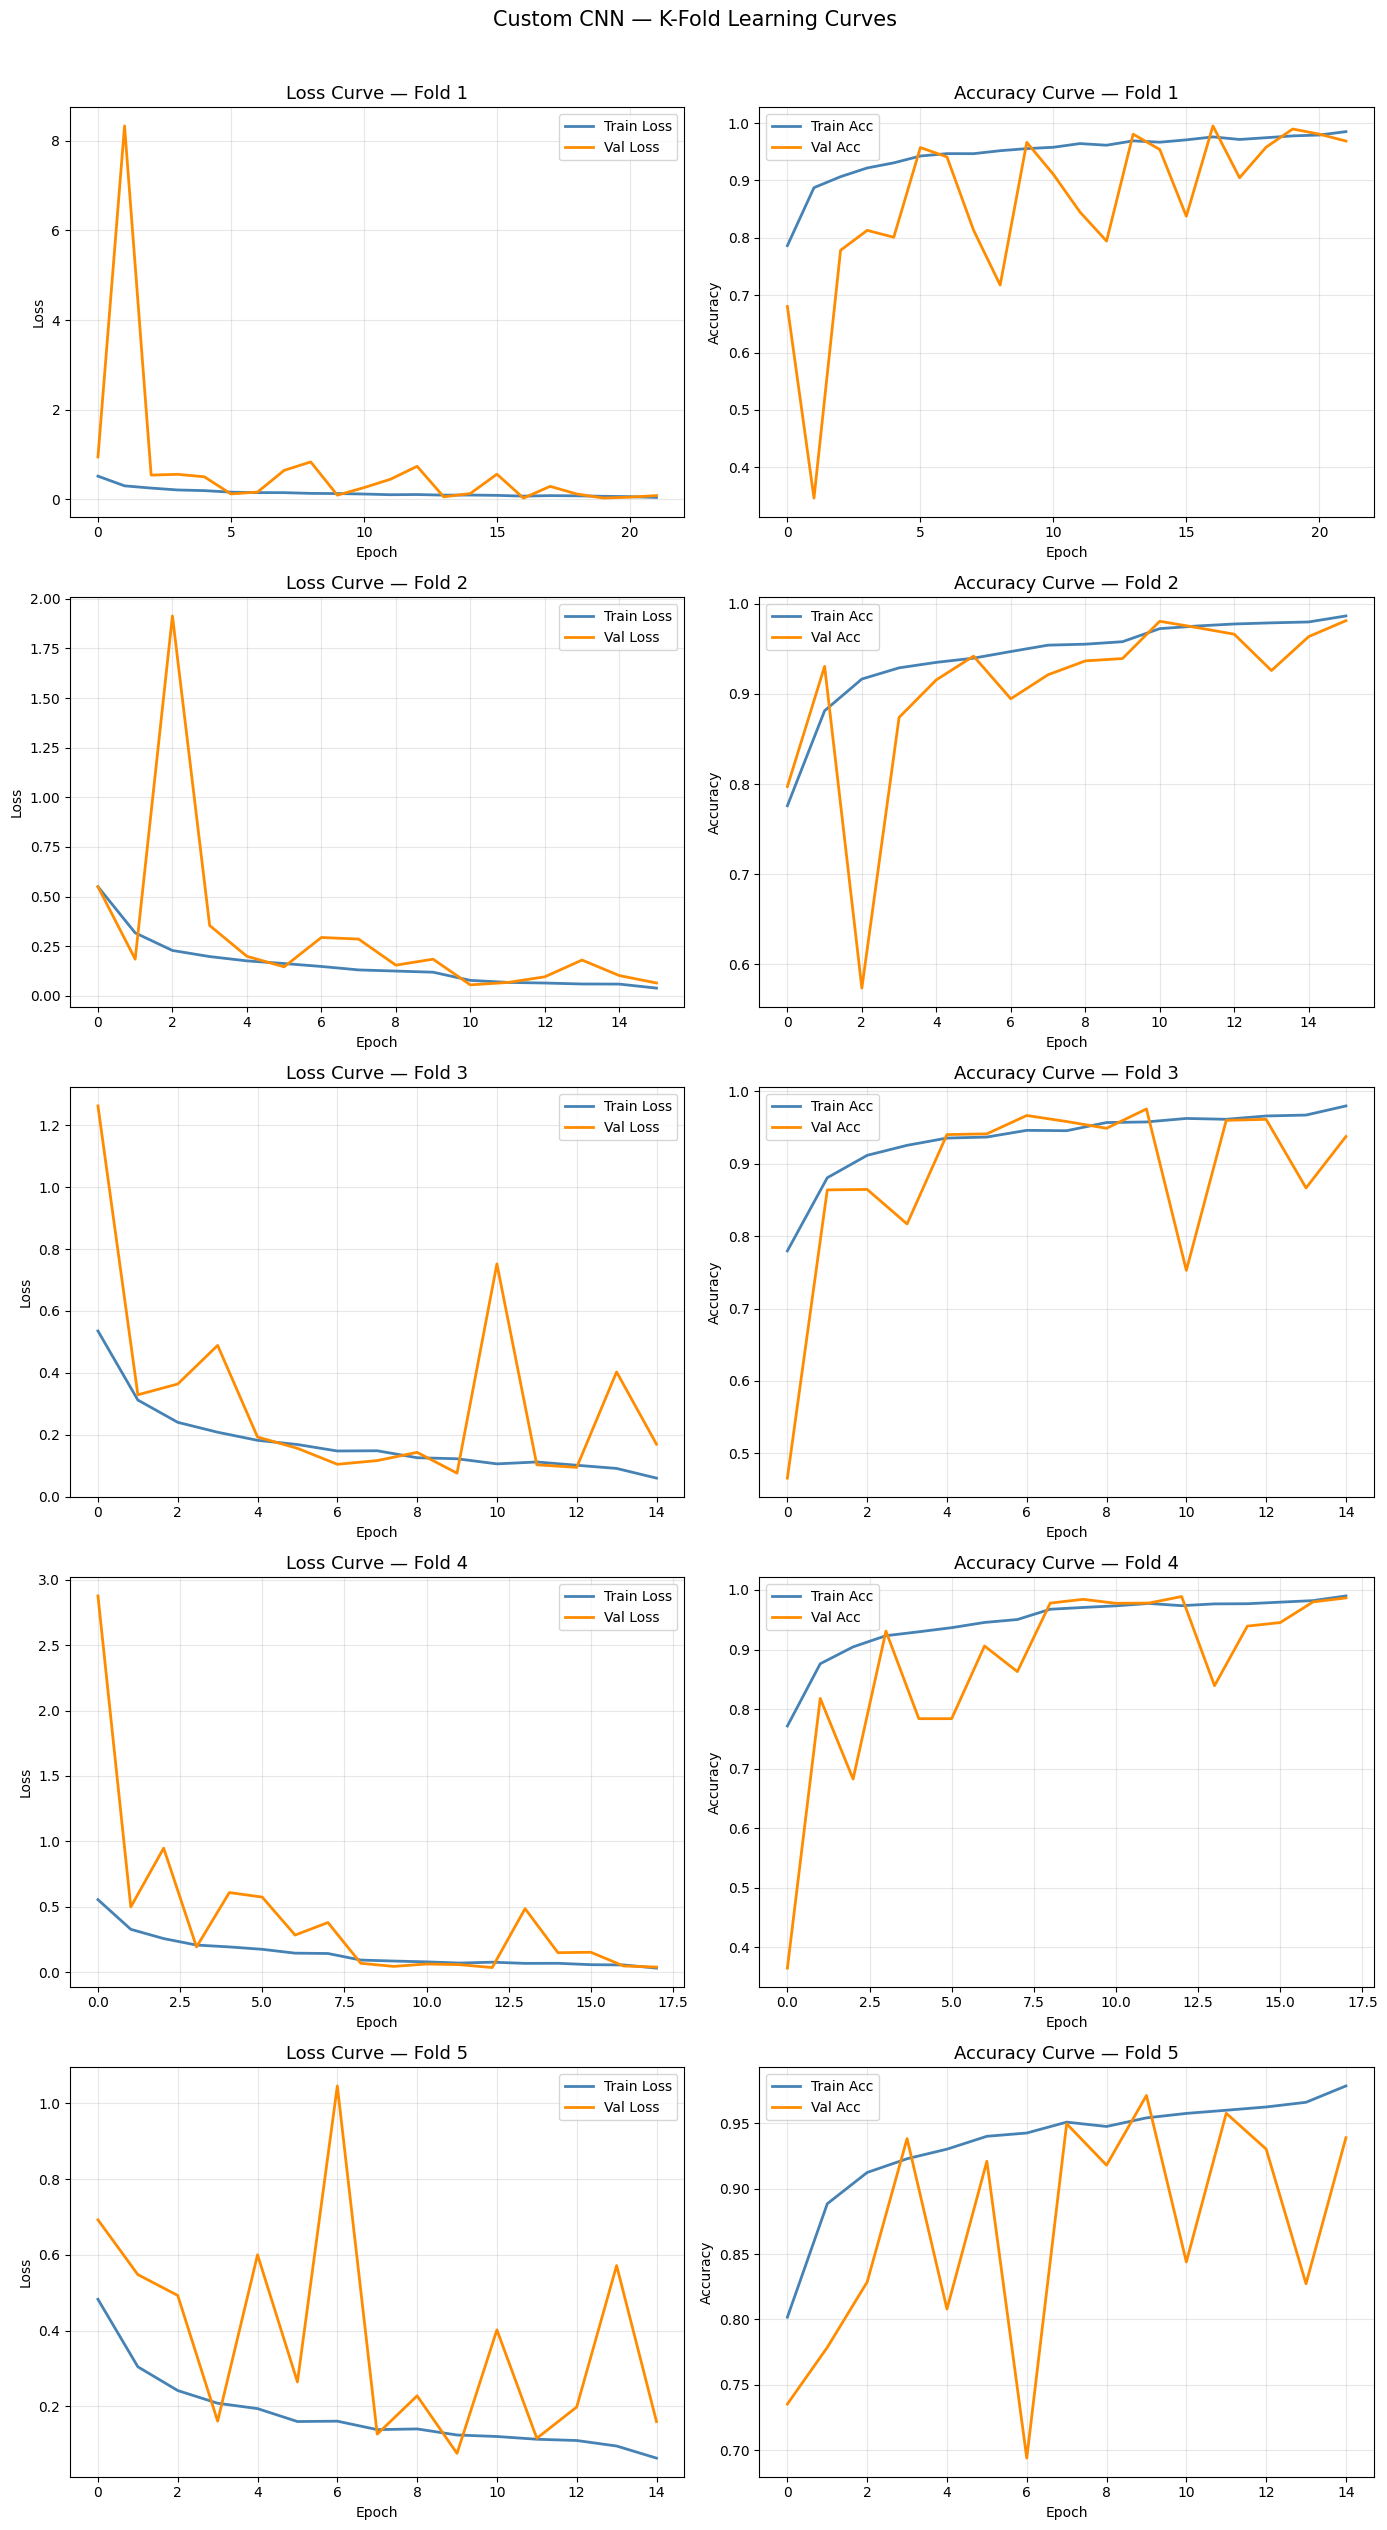

Saved: task3_learning_curves.png


In [9]:
# Visualize training progress
# If val_loss keeps going UP while train_loss goes DOWN → overfitting
# Good training: both curves go down together and converge

colors_train = 'steelblue'
colors_val   = 'darkorange'

fig, axes = plt.subplots(len(fold_histories), 2,
                         figsize=(14, 5 * len(fold_histories)))

if len(fold_histories) == 1:
    axes = [axes]

for fold_idx, h in enumerate(fold_histories):
    ax_loss, ax_acc = axes[fold_idx]

    ax_loss.plot(h['train_loss'], label='Train Loss', color=colors_train, lw=2)
    ax_loss.plot(h['val_loss'],   label='Val Loss',   color=colors_val,   lw=2)
    ax_loss.set_title(f'Loss Curve — Fold {fold_idx+1}', fontsize=13)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_acc.plot(h['train_acc'], label='Train Acc', color=colors_train, lw=2)
    ax_acc.plot(h['val_acc'],   label='Val Acc',   color=colors_val,   lw=2)
    ax_acc.set_title(f'Accuracy Curve — Fold {fold_idx+1}', fontsize=13)
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.suptitle('Custom CNN — K-Fold Learning Curves', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('task3_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_learning_curves.png')

In [10]:
# Load the BEST saved model (not the last epoch — the best val_loss epoch)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

model.eval()
all_preds, all_labels, all_probs = [], [], []

test_start = time.time()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)

        # softmax converts raw scores (logits) → probabilities that sum to 1
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()   # predicted class index

        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_time  = time.time() - test_start
all_probs  = np.vstack(all_probs)   # shape: (num_test_samples, num_classes)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Compute all required metrics ---
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
auc       = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
# OvR = One-vs-Rest: calculates AUC for each class against all others, then averages

print('='*55)
print('     TASK 3 — Custom CNN — Test Results')
print('='*55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC (OvR) : {auc:.4f}')
print(f'  Train Time: {train_time:.1f}s')
print(f'  Test Time : {test_time:.4f}s')
print('='*55)
print('\nDetailed Per-Class Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

     TASK 3 — Custom CNN — Test Results
  Accuracy  : 0.9713  (97.13%)
  Precision : 0.9717
  Recall    : 0.9713
  F1-Score  : 0.9713
  AUC (OvR) : 0.9989
  Train Time: 7361.3s
  Test Time : 4.7939s

Detailed Per-Class Report:
              precision    recall  f1-score   support

brain_glioma       0.97      0.99      0.98       498
 brain_menin       0.95      0.97      0.96       474
 brain_tumor       0.99      0.96      0.97       528

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



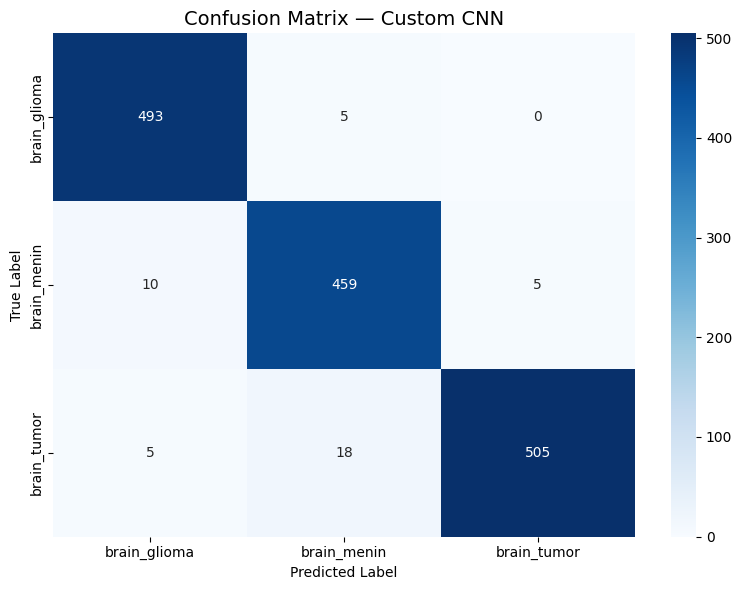

In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # show numbers inside cells
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — Custom CNN', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150)
plt.show()

# How to read this:
# Diagonal cells = correct predictions
# Off-diagonal cells = mistakes (which class is confused with which)

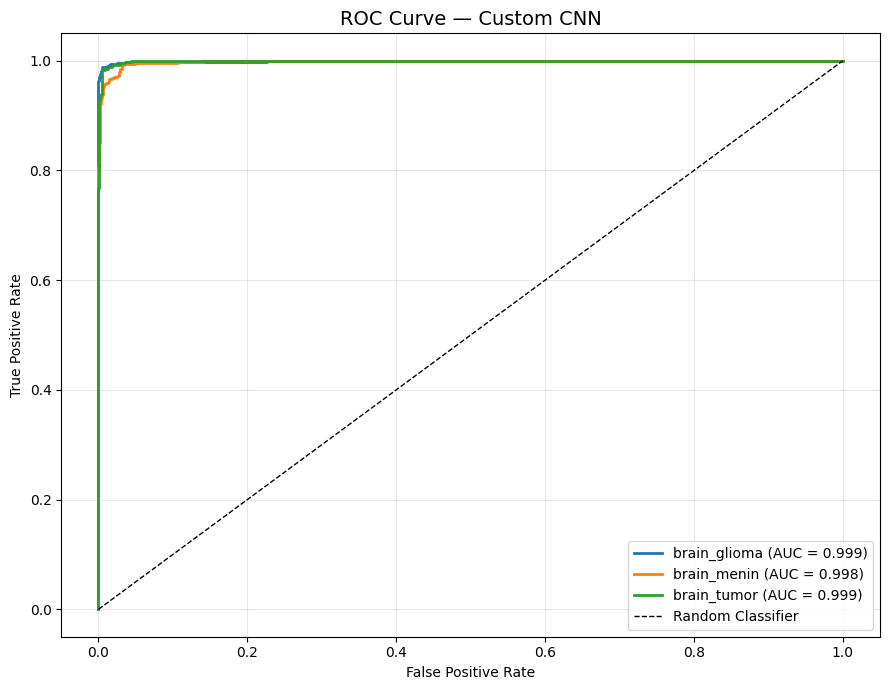

In [12]:
# One-vs-Rest ROC curve: for each class, plot True Positive Rate vs False Positive Rate
# AUC = Area Under Curve — closer to 1.0 = better

y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
# converts labels like [0,1,2,3] → one-hot [[1,0,0,0],[0,1,0,0],...]

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10.colors

for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_i       = roc_auc_score(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC = {auc_i:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Custom CNN', fontsize=14)
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task3_roc_curve.png', dpi=150)
plt.show()

In [13]:
import json

# Save predictions and metrics so Task 4 can compare against Task 3
task3_results = {
    'model'      : 'Custom CNN',
    'accuracy'   : float(acc),
    'precision'  : float(precision),
    'recall'     : float(recall),
    'f1'         : float(f1),
    'auc'        : float(auc),
    'train_time' : float(train_time),
    'test_time'  : float(test_time),
    'all_preds'  : all_preds.tolist(),
    'all_labels' : all_labels.tolist(),
    'all_probs'  : all_probs.tolist()
}

with open('task3_results.json', 'w') as f:
    json.dump(task3_results, f)

print('✓ Saved task3_results.json — use this in Task 4 for comparison!')

✓ Saved task3_results.json — use this in Task 4 for comparison!
